In [1]:
import pandas as pd

# Reading CSV file into a DataFrame
df = pd.read_csv('output/processed_data/sleep_duration_bouts.csv')
df

,patient_id,date,sleep_duration,sleep_bout_count
0,0f352,2019-06-25,0.316667,0
1,0f352,2019-06-26,3.050000,0
2,0f352,2019-06-27,3.950000,0
3,0f352,2019-06-28,4.433333,0
4,0f352,2019-06-29,6.000000,0
...,...,...,...,...
830,f220c,2019-06-24,4.566667,0
831,f220c,2019-06-25,4.033333,0
832,f220c,2019-06-26,0.916667,0
833,f220c,2019-06-29,0.300000,0


0f352
16f4b
1fbe4
30a32
55cd4
76230
93c14
96adf
a2849
b0455
c55f8
c5785
c8574
d7a46
e2472
ec812
f220c


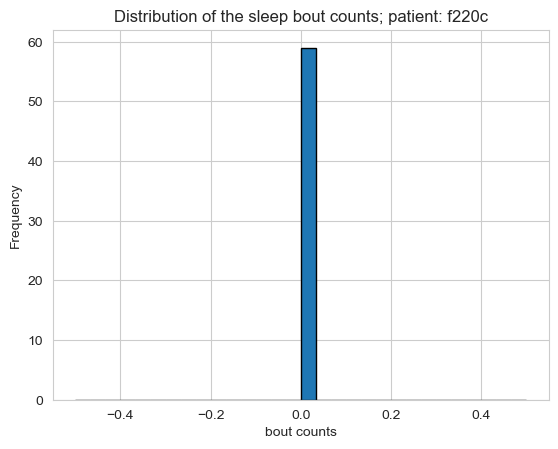

In [6]:
# output bout distribution for each participant
import matplotlib.pyplot as plt
import numpy as np

sleep_id_array = df.patient_id.unique()
for id_pick in sleep_id_array:
    print(id_pick)
    data = df[df['patient_id'] == id_pick]  # Generating random data from a normal distribution
    plt.clf()
    # Create the histogram
    plt.hist(data.sleep_bout_count, bins=30, edgecolor='black')  # bins=30 defines the number of bins
    plt.title('Distribution of the sleep bout counts; patient: ' + str(id_pick))
    plt.xlabel('bout counts')
    plt.ylabel('Frequency')
    
    # Show the plot
    # plt.show()
    plt.savefig('output/bout_distribution/distribution_'+ str(id_pick)+'.png')


0f352
16f4b
1fbe4
30a32
55cd4
76230
93c14
96adf
a2849
b0455
c55f8
c5785
c8574
d7a46
e2472
ec812
f220c


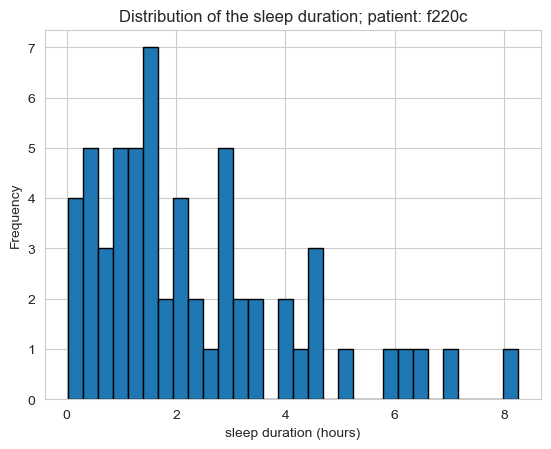

In [8]:
# output bout distribution for each participant
import matplotlib.pyplot as plt
import numpy as np

sleep_id_array = df.patient_id.unique()
for id_pick in sleep_id_array:
    print(id_pick)
    data = df[df['patient_id'] == id_pick]  # Generating random data from a normal distribution
    plt.clf()
    # Create the histogram
    plt.hist(data.sleep_duration, bins=30, edgecolor='black')  # bins=30 defines the number of bins
    plt.title('Distribution of the sleep duration; patient: ' + str(id_pick))
    plt.xlabel('sleep duration (hours)')
    plt.ylabel('Frequency')
    
    # Show the plot
    # plt.show()
    plt.savefig('output/sleep_duration_distribution/distribution_'+ str(id_pick)+'.png')

0f352
16f4b
1fbe4
30a32
55cd4
76230
93c14
96adf
a2849
b0455
c55f8
c5785
c8574
d7a46
e2472
ec812
f220c


<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

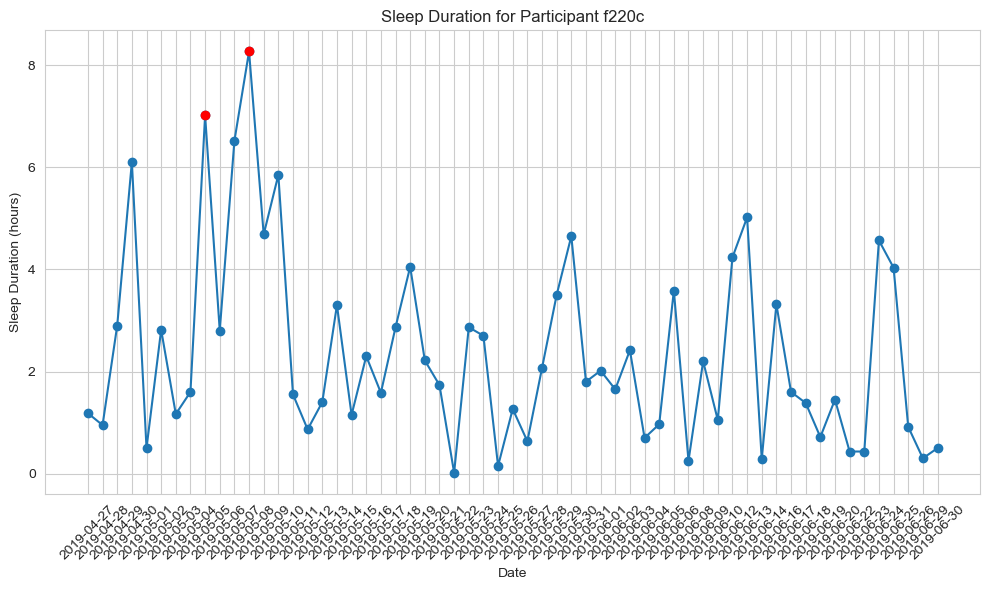

In [21]:
#time series of sleep duration
from pyod.models.mad import MAD
anomaly_df_list = []

sleep_id_array = df.patient_id.unique()
for id_pick in sleep_id_array:
    print(id_pick)
    data = df[df['patient_id'] == id_pick]  # Generating random data from a normal distribution
 
 # calculate MAD score
    # Extract the feature we want
    X = data[["sleep_duration"]]
    # Initialize and fit a model
    mad = MAD(contamination = 0.1, threshold = 3).fit(X)
    # Extract the outlier labels
    labels = mad.labels_
 
 
    plt.clf()
    
    # Plot the time series
    plt.figure(figsize=(10, 6))
    plt.plot(data['date'], data['sleep_duration'], marker='o')
 
     # Highlight anomalies by plotting red markers at the anomaly positions
    anomalies = data[labels == 1]  # Filter data where label is 1 (anomaly)
    plt.scatter(anomalies['date'], anomalies['sleep_duration'], color='red', label='Anomaly', zorder=5)
    anomaly_df_list.append(anomalies)
      
    # Adding labels and title
    plt.title(f"Sleep Duration for Participant {id_pick}")
    plt.xlabel('Date')
    plt.ylabel('Sleep Duration (hours)')
    plt.xticks(rotation=45)  # Rotate dates for better readability
    plt.tight_layout()
    plt.savefig('output/sleep_duration_TimeSeries/TimeSeries_'+ str(id_pick)+'.png')

In [29]:
final_df = pd.concat(anomaly_df_list, ignore_index=True)
final_df  = final_df[['patient_id', 'date', 'sleep_duration']]
final_df.rename(columns={'sleep_duration':'sleepAnomaly'}, inplace=True)
final_df.sleepAnomaly = 1
final_df.to_csv('output/processed_data/sleep_duration_anomalies.csv', index=False)
final_df

,patient_id,date,sleepAnomaly
0,0f352,2019-06-25,1
1,16f4b,2019-04-27,1
2,16f4b,2019-05-03,1
3,16f4b,2019-05-08,1
4,1fbe4,2019-04-24,1
5,1fbe4,2019-05-06,1
6,1fbe4,2019-05-12,1
7,1fbe4,2019-05-17,1
8,1fbe4,2019-05-23,1
9,1fbe4,2019-06-17,1
